# Cox Regression Penalized

### Imports

In [286]:
# Import necessary libraries
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sksurv.ensemble import RandomSurvivalForest
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import concordance_index_censored , concordance_index_ipcw
from sklearn.impute import SimpleImputer
from sksurv.util import Surv

# Clinical Data
df = pd.read_csv("./data/X_train/clinical_train.csv")
df_eval = pd.read_csv("./data/X_test/clinical_test.csv")

# Molecular Data
maf_df = pd.read_csv("./data/X_train/molecular_train.csv")
maf_eval = pd.read_csv("./data/X_test/molecular_test.csv")

target_df = pd.read_csv("./data/target_train.csv")

# TODO : Uncomment for test data ??
"""
target_df_test = pd.read_csv("./data/target_test.csv")
"""
# Preview the data
df.head()

,ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS
0,P132697,MSK,14.0,2.8,0.2,0.7,7.6,119.0,"46,xy,del(20)(q12)[2]/46,xy[18]"
1,P132698,MSK,1.0,7.4,2.4,0.1,11.6,42.0,"46,xx"
2,P116889,MSK,15.0,3.7,2.1,0.1,14.2,81.0,"46,xy,t(3;3)(q25;q27)[8]/46,xy[12]"
3,P132699,MSK,1.0,3.9,1.9,0.1,8.9,77.0,"46,xy,del(3)(q26q27)[15]/46,xy[5]"
4,P132700,MSK,6.0,128.0,9.7,0.9,11.1,195.0,"46,xx,t(3;9)(p13;q22)[10]/46,xx[10]"


### Cleaning

In [287]:
# Drop rows where 'OS_YEARS' is NaN if conversion caused any issues
target_df.dropna(subset=['OS_YEARS', 'OS_STATUS'], inplace=True)


# Check the data types to ensure 'OS_STATUS' is boolean and 'OS_YEARS' is numeric
print(target_df[['OS_STATUS', 'OS_YEARS']].dtypes)

# Contarget_dfvert 'OS_YEARS' to numeric if it isn’t already
target_df['OS_YEARS'] = pd.to_numeric(target_df['OS_YEARS'], errors='coerce')

# Ensure 'OS_STATUS' is boolean
target_df['OS_STATUS'] = target_df['OS_STATUS'].astype(bool)

OS_STATUS    float64
OS_YEARS     float64
dtype: object


0. Parsing functions

In [288]:
total_features = []
def parse_EFFECT():
    maf_df = globals()['maf_df']
    maf_eval = globals()['maf_eval']

    effect_vaf = maf_df.groupby(['ID', 'EFFECT'])['VAF'].max().unstack(fill_value=0)
    effect_vaf_eval = maf_eval.groupby(['ID', 'EFFECT'])['VAF'].max().unstack(fill_value=0)

    effect_vaf.columns = [f"EFFECT_{col}" for col in effect_vaf.columns]
    for col in effect_vaf.columns:
        if col not in effect_vaf_eval.columns:
            effect_vaf_eval[col] = 0
        else:
            effect_vaf_eval[col] = effect_vaf_eval[col]
    globals()['df'] = df.merge(effect_vaf.reset_index(), on='ID', how='left')
    globals()['df_eval'] = df_eval.merge(effect_vaf_eval.reset_index(), on='ID', how='left')
    globals()['total_features'] += list(effect_vaf.columns)

def parse_PROTEIN_CHANGE(protein):
    protein = str(protein)

    if len(protein) == 0 or len(protein) == 1:
        return pd.NA
    
    try:
        protein = str(protein.split('.')[1])
    
    except IndexError:
        return pd.NA
    
    if protein == '?' or protein[0] == '*':
        return pd.NA
    
    else:
        return protein[0].lower()
    
def parse_REF(ref):
    ref = str(ref)
    if len(ref) == 0:
        return pd.NA
    elif ref[0] == '-':
        return pd.NA
    else:
        return ref[0]
    
def parse_ALT(ref):
    ref = str(ref)
    if len(ref) == 0:
        return pd.NA
    elif ref[0] == '-':
        return pd.NA
    else:
        return ref[0]
    
def parse_CHR(chr):
    chr = str(chr)
    if chr not in ['1','2','3','4','5','6','7','8','9','10',
                   '11','12','13','14','15','16','17','18',
                   '19','20','21','22','X','Y']:
        return pd.NA
    else:
        return chr
    
def parse_GENE(gene):
    gene = str(gene)
    if len(gene) == 0:
        return pd.NA
    elif len(gene) < 4:
        return gene
    else:
        return gene[0:4]

import re
from collections import defaultdict

def parse_CYTO(iscn):
    """
    Extract numeric chromosome gains/losses from an ISCN karyotype string,
    ignoring +mar or +nmar patterns.
    """
    iscn = str(iscn)
    iscn = iscn.upper()
    results = defaultdict(int)
    clones = iscn.replace(" ", "").split("/")
    total_observations = 0

    for clone in clones:
        clone = clone.strip()

        # extract clone count [n] or [n/m]
        count_match = re.search(r"\[(\d+)", clone)
        count = int(count_match.group(1)) if count_match else 1
        total_observations += count

        # detect normal clone
        if re.match(r"46,[XY]{2}", clone.replace(" ", "")) and "+" and "-" not in clone:
            results["normal"] += count

        # extract +n or -n NOT followed by letters (exclude mar) only if n is in {1,...,21} or in [X,Y]
        numeric_changes = re.findall(r"([+-])(\d+|X|Y)(?=[,/ \]]|$)", clone)

        for sign, num in numeric_changes:
            if str(num) not in [str(i) for i in range(1, 22)] + ['X', 'Y']:
                continue
            key = f"{sign}{num}"
            results[key] += count
    # Normalize counts to proportions
    for key in results:
        results[key] = np.round(results[key] / total_observations, 2)

    return dict(results)

1. Extracting number of somatic mutations and cytogenetics parsing

In [289]:
# Step: Extract the number of somatic mutations per patient

# Merge with the training dataset and replace missing values in 'Nmut' with 0
if 'Nmut' not in df.columns:
    # Group by 'ID' and count the number of mutations (rows) per patient
    tmp = maf_df.groupby('ID').size().reset_index(name='Nmut')
    tmp_eval = maf_eval.groupby('ID').size().reset_index(name='Nmut')
    
    df = df.merge(tmp, on='ID', how='left').fillna({'Nmut': 0})
    df_eval = df_eval.merge(tmp_eval, on='ID', how='left').fillna({'Nmut': 0})

if '+X' not in df.columns:
    # Apply the parse_cytogenetics function to create a new column with parsed abnormalities
    cytogenetics_labels = ['+' + str(i) for i in range(1,22)] + ['-' + str(i) for i in range(1,22)] + ['normal'] + ['+X', '+Y', '-X', '-Y']

    df['CYTOGENETICS_ABNORMALITIES'] = df['CYTOGENETICS'].apply(parse_CYTO)
    df_eval['CYTOGENETICS_ABNORMALITIES'] = df_eval['CYTOGENETICS'].apply(parse_CYTO)

    # Expand the abnormalities into separate columns
    for label in cytogenetics_labels:
        df[f'{label}'] = df['CYTOGENETICS_ABNORMALITIES'].apply(lambda x: x.get(label, 0) if isinstance(x, dict) else 0)
        df_eval[f'{label}'] = df_eval['CYTOGENETICS_ABNORMALITIES'].apply(lambda x: x.get(label, 0) if isinstance(x, dict) else 0)

    for label in cytogenetics_labels:
        if df[f'{label}'].sum() == 0:
            df.drop(columns=[f'{label}'], inplace=True)
            df_eval.drop(columns=[f'{label}'], inplace=True)
        else:
            total_features.append(f'{label}') 

    # Drop the original 'CYTOGENETICS' and temporary columns
    df.drop(columns=['CYTOGENETICS', 'CYTOGENETICS_ABNORMALITIES'], inplace=True)
    df_eval.drop(columns=['CYTOGENETICS', 'CYTOGENETICS_ABNORMALITIES'], inplace=True)
    
df.head()

,ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,Nmut,+1,...,-17,-18,-19,-20,-21,normal,+X,+Y,-X,-Y
0,P132697,MSK,14.0,2.8,0.2,0.7,7.6,119.0,9.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,P132698,MSK,1.0,7.4,2.4,0.1,11.6,42.0,3.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,P116889,MSK,15.0,3.7,2.1,0.1,14.2,81.0,3.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,P132699,MSK,1.0,3.9,1.9,0.1,8.9,77.0,11.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,P132700,MSK,6.0,128.0,9.7,0.9,11.1,195.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


2. One hot encoding 'GENE', 'EFFECT' and 2 first relevant characters of 'PROTEIN_CHANGE'

In [290]:
def add_feature(features_list):
    df = globals()['df']
    df_eval = globals()['df_eval']
    total_features = globals()['total_features']
    for feature in features_list:
        if feature != 'EFFECT':
            if feature in df.columns:
                print(f"Feature \'{feature}\' already exists. Skipping...")
                continue
            parse_function = globals().get(f'parse_{feature}')
            if parse_function:
                one_hot_encoded_feature = pd.get_dummies(maf_df[feature].apply(parse_function), prefix=feature)
                one_hot_encoded_eval = pd.get_dummies(maf_eval[feature].apply(parse_function), prefix=feature)
            else:
                raise ValueError(f"No function named 'parse_{feature}' found.")
            
            maf_df_one_hot_feature = pd.concat([maf_df[['ID']], one_hot_encoded_feature], axis=1)
            maf_eval_one_hot_feature = pd.concat([maf_eval[['ID']], one_hot_encoded_eval], axis=1)

            maf_df_feature_agg = maf_df_one_hot_feature.groupby('ID').max().reset_index()
            maf_eval_feature_agg = maf_eval_one_hot_feature.groupby('ID').max().reset_index()

            # Merge all new columns at once
            df = df.merge(maf_df_feature_agg.fillna(0), on='ID', how='left')
            df_eval = df_eval.merge(maf_eval_feature_agg.fillna(0), on='ID', how='left')
            total_features = total_features + list(maf_df_feature_agg.drop(columns=['ID']).columns)
        elif feature == 'EFFECT':
            parse_EFFECT()
            print(f"Added feature: {feature}")

    # Update the global variables
    globals()['df'] = df
    globals()['df_eval'] = df_eval
    globals()['total_features'] = total_features

add_feature(['GENE', 'PROTEIN_CHANGE', 'REF', 'ALT'])

### 3. Training

1. Selecting features and getting rid of rows with NaN values in training set

In [291]:
# Select features and target columns
features = ['BM_BLAST', 'HB', 'PLT', 'ANC','WBC','MONOCYTES','Nmut']
total_features = total_features + features

# target features
target = ['OS_YEARS', 'OS_STATUS']

# Remove rows with missing feature values
df = df.merge(target_df[['ID', 'OS_YEARS', 'OS_STATUS']], on='ID', how='inner')
df = df.dropna()

# Build feature matrix and survival target
X = df[total_features]
y = Surv.from_dataframe('OS_STATUS', 'OS_YEARS', df[target])
X.head

<bound method NDFrame.head of        +1   +2   +3   +5   +6   +7   +8   +9  +10  +11  ...  ALT_G  ALT_T  \
0     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   True   True   
1     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  False   True   
2     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  False  False   
3     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   True   True   
4     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  False  False   
...   ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...    ...    ...   
3168  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  False   True   
3169  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  False   True   
3170  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   True   True   
3171  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   True  False   
3172  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   True   True   

      ALT_n  BM_BLAST    HB    PLT   ANC     

In [292]:
X_eval = df_eval['ID']
for col in list(X.columns):
    if col in list(df_eval.columns):
        X_eval = pd.DataFrame(X_eval).merge(df_eval[['ID', col]], on='ID', how='left')
    else:
        X_eval[col] = pd.NA
X_eval.drop(columns=['ID'], inplace=True)
X_eval.head()

,+1,+2,+3,+5,+6,+7,+8,+9,+10,+11,...,ALT_G,ALT_T,ALT_n,BM_BLAST,HB,PLT,ANC,WBC,MONOCYTES,Nmut
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,True,True,68.0,7.6,48.0,0.5865,3.45,NaN,4.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,True,False,35.0,10.0,32.0,1.2402,3.18,NaN,3.0
2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,False,True,False,NaN,12.3,25.0,8.6800,12.40,NaN,3.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,True,False,True,61.0,8.0,44.0,2.0535,5.55,NaN,3.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,True,False,2.0,8.6,27.0,0.7381,1.21,NaN,3.0


2. Spliting dataset

In [293]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)
X_train.head()

,+1,+2,+3,+5,+6,+7,+8,+9,+10,+11,...,ALT_G,ALT_T,ALT_n,BM_BLAST,HB,PLT,ANC,WBC,MONOCYTES,Nmut
914,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,True,False,5.5,6.0,460.0,1.080,3.80,0.310,3.0
692,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,True,True,False,5.0,8.6,80.0,1.218,2.10,0.315,5.0
2199,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,True,True,False,0.5,12.1,241.0,2.300,4.80,0.300,4.0
1199,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,True,False,0.0,12.6,59.0,1.530,3.09,0.120,1.0
932,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,True,False,8.5,5.5,63.0,1.100,2.10,0.210,4.0


3. Fitting Cox Ridge model

In [294]:
# Initialize and train the Cox Proportional Hazards model
cox = CoxnetSurvivalAnalysis(l1_ratio=1, alpha_min_ratio=0.1, max_iter=10000, normalize=True)
cox.fit(X_train, y_train)

# Evaluate the model using Concordance Index IPC
cox_cindex_train = concordance_index_ipcw(y_train, y_train, cox.predict(X_train), tau=7)[0]
cox_cindex_test = concordance_index_ipcw(y_train, y_test, cox.predict(X_test), tau=7)[0]
print(f"Cox Proportional Hazard Model Concordance Index IPCW on train: {100*cox_cindex_train:.3f}")
print(f"Cox Proportional Hazard Model Concordance Index IPCW on test: {100*cox_cindex_test:.3f}")

Cox Proportional Hazard Model Concordance Index IPCW on train: 73.272
Cox Proportional Hazard Model Concordance Index IPCW on test: 70.336


4. Visualizing feature's relevance

<Figure size 1000x600 with 0 Axes>

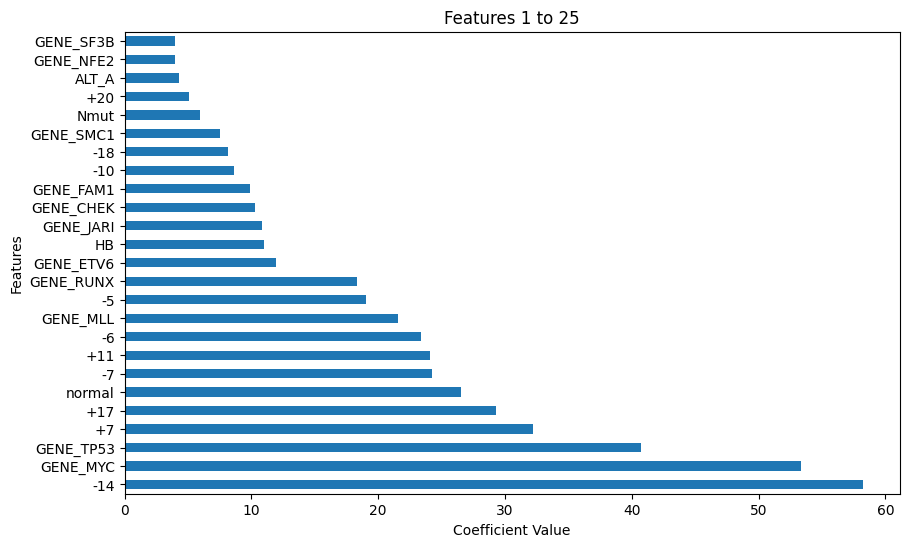

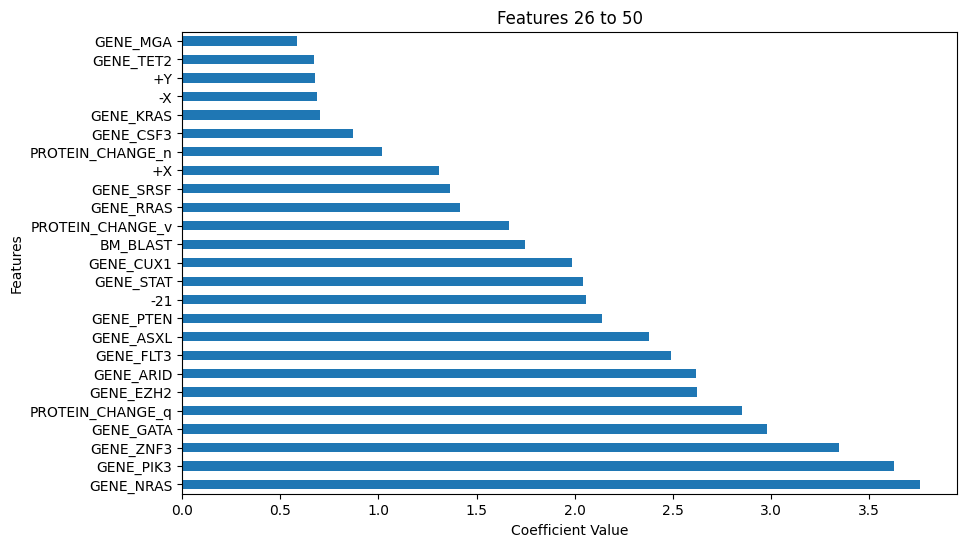

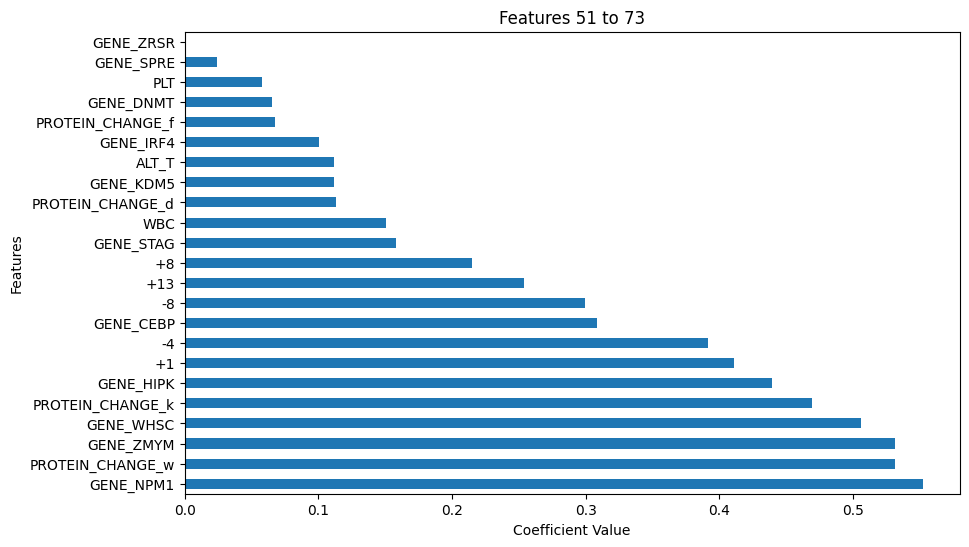

In [295]:
# Print non-zero coefficients number for each feature in chunks of 25
coefs = pd.Series(np.abs(cox.coef_).sum(axis=1), index=X_train.columns)
coefs = coefs.sort_values(ascending=False)
coefs = coefs[coefs > 0]

plt.figure(figsize=(10, 6))
chunk_size = 25
for i in range(0, len(coefs), chunk_size):
    chunk = coefs.iloc[i:i + chunk_size]
    plt.figure(figsize=(10, 6))
    chunk.plot(kind='barh')
    plt.title(f'Features {i + 1} to {i + len(chunk)}')
    plt.xlabel('Coefficient Value')
    plt.ylabel('Features')
    plt.show()

relevant_features = coefs.index.tolist()

5. Using relevant features

In [300]:
features = [feature for feature in features if relevant_features.count(feature) > 0]
print(features)
X_train_relevant = X_train[relevant_features]
X_test_relevant = X_test[relevant_features]
X_eval_relevant = X_eval[relevant_features]

X_train_relevant.head()

['BM_BLAST', 'HB', 'PLT', 'WBC', 'Nmut']


,-14,GENE_MYC,GENE_TP53,+7,+17,normal,-7,+11,-6,GENE_MLL,...,WBC,PROTEIN_CHANGE_d,GENE_KDM5,ALT_T,GENE_IRF4,PROTEIN_CHANGE_f,GENE_DNMT,PLT,GENE_SPRE,GENE_ZRSR
914,0.0,False,False,0.0,0.0,1.00,0.0,0.0,0.0,False,...,3.80,False,False,True,False,False,True,460.0,False,False
692,0.0,False,False,0.0,0.0,0.59,0.0,0.0,0.0,False,...,2.10,True,False,True,False,False,False,80.0,False,False
2199,0.0,False,True,0.0,0.0,1.00,0.0,0.0,0.0,False,...,4.80,False,False,True,False,False,True,241.0,False,False
1199,0.0,False,True,0.0,0.0,0.30,0.0,0.0,0.0,False,...,3.09,False,False,True,False,False,False,59.0,False,False
932,0.0,False,False,0.0,0.0,0.00,0.0,0.0,0.0,False,...,2.10,False,False,True,False,False,False,63.0,False,False


In [301]:
cox = CoxnetSurvivalAnalysis(l1_ratio=0.5, alpha_min_ratio=0.0001, max_iter=10000, normalize=False)
cox.fit(X_train_relevant, y_train)

# Evaluate the model using Concordance Index IPC
cox_cindex_train = concordance_index_ipcw(y_train, y_train, cox.predict(X_train_relevant), tau=7)[0]
cox_cindex_test = concordance_index_ipcw(y_train, y_test, cox.predict(X_test_relevant), tau=7)[0]
print(f"Cox Proportional Hazard Model Concordance Index IPCW on train: {100*cox_cindex_train:.3f}")
print(f"Cox Proportional Hazard Model Concordance Index IPCW on test: {100*cox_cindex_test:.3f}")

Cox Proportional Hazard Model Concordance Index IPCW on train: 72.724
Cox Proportional Hazard Model Concordance Index IPCW on test: 70.433


### 4. Prediction

3. Imputer with median strategy

In [304]:
imputer = SimpleImputer(strategy='median')
print(features)
X_train_relevant[features] = imputer.fit_transform(X_train_relevant[features])
X_eval_relevant[features] = imputer.transform(X_eval_relevant[features])
X_eval_relevant = X_eval_relevant.fillna(False)
X_eval_relevant.head()

['BM_BLAST', 'HB', 'PLT', 'WBC', 'Nmut']


/tmp/ipykernel_155793/4000338104.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_relevant[features] = imputer.fit_transform(X_train_relevant[features])


,-14,GENE_MYC,GENE_TP53,+7,+17,normal,-7,+11,-6,GENE_MLL,...,WBC,PROTEIN_CHANGE_d,GENE_KDM5,ALT_T,GENE_IRF4,PROTEIN_CHANGE_f,GENE_DNMT,PLT,GENE_SPRE,GENE_ZRSR
0,0.0,False,False,0.0,0.0,0.0,0.00,0.0,0.0,False,...,3.45,False,False,True,False,False,True,48.0,False,False
1,0.0,False,False,0.0,0.0,1.0,0.00,0.0,0.0,False,...,3.18,False,False,True,False,False,False,32.0,False,False
2,0.0,False,False,0.0,0.0,0.0,0.00,0.0,0.0,False,...,12.40,False,False,True,False,False,False,25.0,False,False
3,0.0,False,False,0.0,0.0,0.0,0.00,0.0,0.0,False,...,5.55,False,False,False,False,False,False,44.0,False,False
4,0.0,False,False,0.0,0.0,0.0,0.75,0.0,0.0,False,...,1.21,False,False,True,False,False,False,27.0,False,False


In [305]:
prediction_on_test_set = cox.predict(X_eval_relevant)
prediction_on_test_set

array([ 2.13971761,  0.55859542, -0.09173956, ...,  0.7035685 ,
        0.26529724,  0.63502527])

In [306]:
submission = pd.Series(prediction_on_test_set, index=df_eval['ID'], name='risk_score')

In [307]:
submission.to_csv('./submission/cox_ridge_submission.csv')

In [308]:
submission.head()

ID
KYW1    2.139718
KYW2    0.558595
KYW3   -0.091740
KYW4    2.216051
KYW5    0.774691
Name: risk_score, dtype: float64